## 📄 Obesity Risk Classification
**Purpose:** This notebook is dedicated to cleaning, exploring, and preprocessing the Obesity dataset to train and evaluate a Logistic Regression model for binary classification of obesity risk.
---
## ⚙️ Project Metadata
* **Author:** [Your Name/Team Placeholder]
* **Date:** 2025-12-11
* **Version:** v1.0.0 (Initial Standardized Version)
#### 📜 Version History
* v1.0.0: Initial implementation and standardization per best practices.

## 1. Setup

In [1]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization Libraries ---
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

# --- Scikit-learn Modules ---
# Requires: scikit-learn >= 1.0.0
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score, accuracy_score

In [5]:
# --- Reproducibility ---
# Set global random seeds for reproducibility across experiments.
SEED = 42
np.random.seed(SEED)

## 2. Data Loading and Initial Inspection

In [17]:
# Load the dataset from a CSV file
df = pd.read_csv("datasets/ObesityDataSet_Original.csv")
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 2111 rows and 17 columns.


In [18]:
# Display the first few rows to understand the data structure
df.head(2)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight


In [19]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

## 3. Data Cleaning and Preprocessing

In [20]:
# Standardize column names to lowercase and replace spaces with underscores for consistency
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['gender', 'age', 'height', 'weight', 'family_history_with_overweight',
       'favc', 'fcvc', 'ncp', 'caec', 'smoke', 'ch2o', 'scc', 'faf', 'tue',
       'calc', 'mtrans', 'nobeyesdad'],
      dtype='object')

In [21]:
# Check for any missing values in the dataset
df.isnull().sum()

gender                            0
age                               0
height                            0
weight                            0
family_history_with_overweight    0
favc                              0
fcvc                              0
ncp                               0
caec                              0
smoke                             0
ch2o                              0
scc                               0
faf                               0
tue                               0
calc                              0
mtrans                            0
nobeyesdad                        0
dtype: int64

### 3.1. Target Variable Creation
The original target variable `nobeyesdad` is multi-class. For this project, we will convert it into a binary classification problem: `is_obese` (1) or not (0).

In [22]:
df.nobeyesdad.value_counts()

nobeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [23]:
# Define the categories that are NOT considered obese
non_obese_categories = ["Normal_Weight", "Insufficient_Weight"]

# Create the 'is_obese' target variable: 1 if obese, 0 otherwise
df["is_obese"] = np.where(df["nobeyesdad"].isin(non_obese_categories), 0, 1)

# Drop the original multi-class column
df = df.drop("nobeyesdad", axis=1)

# Verify the distribution of the new binary target variable
df["is_obese"].value_counts()

is_obese
1    1552
0     559
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

In [24]:
# Get a summary of data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          2111 non-null   object 
 1   age                             2111 non-null   float64
 2   height                          2111 non-null   float64
 3   weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   favc                            2111 non-null   object 
 6   fcvc                            2111 non-null   float64
 7   ncp                             2111 non-null   float64
 8   caec                            2111 non-null   object 
 9   smoke                           2111 non-null   object 
 10  ch2o                            2111 non-null   float64
 11  scc                             2111 non-null   object 
 12  faf                             21

In [25]:
# Generate descriptive statistics for numerical columns
df.describe()

,age,height,weight,fcvc,ncp,ch2o,faf,tue,is_obese
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866,0.735197
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927,0.441333
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350,1.000000
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,1.000000


## 5. Feature Importance and Selection

### 5.1. Data Splitting
Before analyzing feature importance, we split the data to prevent data leakage. Importance metrics will be calculated on the training set only.

In [26]:
# Split the data into training (80%) and test (20%) sets
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=SEED)

# Split the full training set into training and validation sets (approx. 67% and 33%)
df_train, df_val = train_test_split(df_train_full, test_size=0.33, random_state=SEED)

# Isolate the target variable (y) from the features (X)
y_train = df_train.is_obese.values
y_val = df_val.is_obese.values
y_test = df_test.is_obese.values

# Remove the target variable from the feature dataframes
df_train = df_train.drop('is_obese', axis=1)
df_val = df_val.drop('is_obese', axis=1)
df_test = df_test.drop('is_obese', axis=1)

print(f"Dataset sizes: Train={len(df_train)}, Validation={len(df_val)}, Test={len(df_test)}")

Dataset sizes: Train=1130, Validation=558, Test=423


### 5.2. Categorical Feature Importance (Mutual Information)
We use Mutual Information to measure the dependency between categorical features and the target variable. A higher score indicates a stronger relationship.

In [27]:
# Identify categorical columns
categorical_cols = df_train_full.select_dtypes(include=['object']).columns.tolist()

# Define a function to calculate mutual information
def calculate_mi(series):
    return mutual_info_score(series, df_train_full.is_obese)

# Apply the function to all categorical columns and sort by importance
df_mi = df_train_full[categorical_cols].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name="MI")
df_mi

,MI
caec,0.116335
family_history_with_overweight,0.109053
favc,0.019980
mtrans,0.014893
calc,0.010908
scc,0.009647
gender,0.002729
smoke,0.000128


### 5.3. Numerical Feature Importance (Correlation)
We use the Pearson correlation coefficient to measure the linear relationship between numerical features and the target. Values closer to 1 or -1 indicate a stronger correlation.

In [28]:
# Identify numerical columns (excluding the target)
numerical_cols = df_train_full.select_dtypes(include=np.number).columns.drop('is_obese').tolist()

# Calculate the correlation of numerical features with the target variable
correlation_matrix = df_train_full[numerical_cols].corrwith(df_train_full.is_obese).to_frame("correlation")

# Sort by the absolute correlation value to see the strongest relationships
correlation_matrix.reindex(correlation_matrix.correlation.abs().sort_values(ascending=False).index)

,correlation
weight,0.695475
age,0.330112
faf,-0.169362
ch2o,0.141729
height,0.122709
ncp,-0.103018
tue,-0.083729
fcvc,0.008449


## 6. Feature Engineering
To prepare the data for the model, we will use one-hot encoding to convert categorical variables into a numerical format.

In [29]:
# Combine categorical and numerical column names for feature selection
features = categorical_cols + numerical_cols

# Initialize the DictVectorizer. sparse=False returns a dense numpy array.
dv = DictVectorizer(sparse=False)

# Convert the training dataframe into a list of dictionaries and fit the vectorizer
train_dict = df_train[features].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

# Transform the validation dataframe using the already-fitted vectorizer
val_dict = df_val[features].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [30]:
# Display the number of features created by the DictVectorizer
f"Number of features after one-hot encoding: {len(dv.get_feature_names_out())}"

'Number of features after one-hot encoding: 31'

## 7. Model Training and Evaluation

### 7.1. Logistic Regression

In [56]:
# Initialize and train the Logistic Regression model
# 'liblinear' is a good solver for smaller datasets.
model = LogisticRegression(solver="liblinear", random_state=SEED)
model.fit(X_train, y_train)


LogisticRegression(random_state=42, solver='liblinear')

In [57]:
# Output of model is two column matrix  - first for 1/negative/ no obses vs seconds for 1/positive/is obese
y_pred = model.predict_proba(X_val)[:, 1]
# Use %50 threshold and convert to True/False
is_obese_pred = y_pred >= 0.5

# Calculate accuracy
(y_val == is_obese_pred).mean()

0.9713261648745519

### 7.2. Model Interpretation
Let's examine the model's intercept and coefficients to understand which features are most influential.

In [73]:
print(type(model.predict_proba))

<class 'method'>


In [50]:
# The intercept is the base log-odds of being obese when all features are zero.
f"Model Intercept (Bias): {model.intercept_[0]:.3f}"

'Model Intercept (Bias): -1.547'

In [33]:
# The coefficients represent the change in the log-odds of the outcome for a one-unit increase in the feature.
# Positive values increase the odds of obesity; negative values decrease it.
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'age': 0.014,
 'caec=Always': -1.459,
 'caec=Frequently': -1.556,
 'caec=Sometimes': 0.573,
 'caec=no': 0.896,
 'calc=Always': -0.074,
 'calc=Frequently': -0.052,
 'calc=Sometimes': -0.4,
 'calc=no': -1.02,
 'ch2o': 0.161,
 'faf': -0.551,
 'family_history_with_overweight=no': -0.952,
 'family_history_with_overweight=yes': -0.594,
 'favc=no': -0.84,
 'favc=yes': -0.707,
 'fcvc': -0.77,
 'gender=Female': 0.166,
 'gender=Male': -1.712,
 'height': -4.93,
 'mtrans=Automobile': -0.443,
 'mtrans=Bike': 0.829,
 'mtrans=Motorbike': -0.306,
 'mtrans=Public_Transportation': -0.462,
 'mtrans=Walking': -1.164,
 'ncp': -0.35,
 'scc=no': -1.283,
 'scc=yes': -0.263,
 'smoke=no': -1.057,
 'smoke=yes': -0.489,
 'tue': 0.077,
 'weight': 0.264}

In [34]:
features

['gender',
 'family_history_with_overweight',
 'favc',
 'caec',
 'smoke',
 'scc',
 'calc',
 'mtrans',
 'age',
 'height',
 'weight',
 'fcvc',
 'ncp',
 'ch2o',
 'faf',
 'tue']

In [35]:
df[features].head()

,gender,family_history_with_overweight,favc,caec,smoke,scc,calc,mtrans,age,height,weight,fcvc,ncp,ch2o,faf,tue
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0
3,Male,no,no,Sometimes,no,no,Frequently,Walking,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0


In [84]:
patient1 = {
    "gender": "Female",
    "family_history_with_overweight": "yes",
    "favc": "yes",
    "caec": "Frequently",
    "smoke": "yes",
    "scc": "no",
    "calc": "no",
    "mtrans": "Public_Transportation",
    "age": 21,
    "height": 53,
    "weight": 80,
    "fcvc": 2.0,
    "ncp": 3.0,
    "ch2o": 2.0,
    "faf": 0.0,
    "tue": 1.0,
}

In [85]:
X_test = dv.transform([patient1])
y_test_pred = model.predict_proba(X_test)[:,1]
y_test_pred

array([4.16014594e-109])

## Accuracy

In [61]:
from sklearn.metrics import accuracy_score

In [62]:
accuracy_score(y_val, y_pred >= 0.5)

0.9713261648745519

In [67]:
thresholds = np.linspace(0, 1, 20)

accuracies = []

for t in thresholds:
    acc = accuracy_score(y_val, y_pred >= t)
    accuracies.append(acc)
    print("%0.2f %0.3f" % (t, acc))

0.00 0.717
0.05 0.910
0.11 0.923
0.16 0.935
0.21 0.944
0.26 0.950
0.32 0.952
0.37 0.962
0.42 0.968
0.47 0.971
0.53 0.973
0.58 0.971
0.63 0.966
0.68 0.964
0.74 0.959
0.79 0.959
0.84 0.937
0.89 0.918
0.95 0.875
1.00 0.283


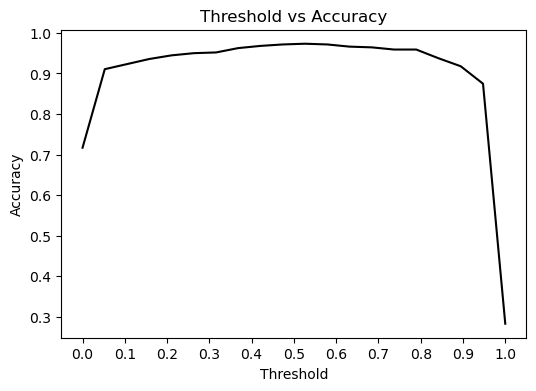

In [68]:

plt.figure(figsize=(6, 4))

plt.plot(thresholds, accuracies, color="black")

plt.title("Threshold vs Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.xticks(np.linspace(0, 1, 11))

# plt.savefig('04_threshold_accuracy.svg')

plt.show()

## Confusion table

In [69]:
true_positive = ((y_pred >= 0.5) & (y_val == 1)).sum()
false_positive = ((y_pred >= 0.5) & (y_val == 0)).sum()
false_negative = ((y_pred < 0.5) & (y_val == 1)).sum()
true_negative = ((y_pred < 0.5) & (y_val == 0)).sum()

In [70]:
confusion_table = np.array(
    # predict neg    pos
    [[true_negative, false_positive], [false_negative, true_positive]]  # actual neg
)  # actual pos

confusion_table

array([[144,  14],
       [  2, 398]])

In [71]:
confusion_table / confusion_table.sum()

array([[0.25806452, 0.02508961],
       [0.00358423, 0.71326165]])

## Precision and recall

In [72]:
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
precision, recall

(0.9660194174757282, 0.995)